# Transfer learning and fine-tuning

### Reusing a network that was trained for something else

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why early layers transfer and late ones do not, the difference between feature extraction and fine-tuning, how the two compare against training from scratch, and how little labelled data you need before transfer stops being worth it |
| **You should already know** | [08-02 A convolutional network, layer by layer](../02-a-cnn-layer-by-layer/) |
| **Dataset** | Fashion-MNIST, split into two separate five-class tasks |
| **Runtime** | Four to six minutes on a laptop CPU, about one on a GPU |
| **Next** | [08-06 Image segmentation](../06-segmentation-intro/) |

---

## 1. The idea

Training a network from random weights takes a lot of labelled examples. Most
real problems do not have a lot of labelled examples. Somebody wants to sort
photographs of their own products, or find one defect on one production line,
and they have a few hundred pictures.

Transfer learning is the answer that made deep learning usable outside large
labs. Take a network someone already trained on a big task, keep its weights,
throw away the last layer, put a new one on top for your classes, and carry on
training. You start from a model that already knows how to look at pictures
instead of from noise.

The reason this works is worth stating carefully, because it is the reason for
everything else in this notebook. The first thing a vision network learns is not
"cat". It is edges. Then corners and blobs, then textures, then object parts,
and only at the very end the categories it was scored on. Edges and textures are
properties of images, not of a label set. They are as useful for sorting X-rays
as they are for sorting dogs, so they carry over. The last layer, which has been
pushed to separate exactly the classes of the source task, carries over least.

**How I set this up.** The honest demonstration would pull an ImageNet-trained
network off the internet, and the cell below tries. But a notebook that only
runs when the network is up is a notebook that stops running, so the whole
experiment here is self-contained: I split Fashion-MNIST into two tasks that
share no classes, train a source model on the first five, and transfer it to the
other five. Same mechanism, same conclusions, a short local training run
instead of a download. If the pretrained weights do load, I use them for one picture where
they make the point better than I can.

In [1]:
import sys
import pathlib
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} on {device}")

train_set = datasets.fashion_mnist(train=True)
test_set = datasets.fashion_mnist(train=False)
CLASSES = ["T-shirt", "trouser", "pullover", "dress", "coat",
           "sandal", "shirt", "sneaker", "bag", "boot"]
print(f"{len(train_set):,} training images, {len(test_set):,} test images, 28x28 greyscale")

torch 2.11.0+cu128 on cuda


60,000 training images, 10,000 test images, 28x28 greyscale


In [2]:
# Two tasks that share no labels. The source task gets all its data; the target
# task is the one I will starve of examples on purpose.
SOURCE_CLASSES = [0, 1, 2, 3, 4]
TARGET_CLASSES = [5, 6, 7, 8, 9]


class Relabelled(torch.utils.data.Dataset):
    """Same images, labels renumbered so a five-class task runs 0 to 4."""

    def __init__(self, base, classes):
        self.base = base
        self.lookup = {original: new for new, original in enumerate(classes)}

    def __len__(self):
        return len(self.base)

    def __getitem__(self, position):
        image, label = self.base[position]
        return image, self.lookup[int(label)]


def indices_for(dataset, classes):
    """Positions in `dataset` whose label is one of `classes`."""
    labels = torch.as_tensor(dataset.targets)
    keep = torch.isin(labels, torch.tensor(classes))
    return keep.nonzero(as_tuple=True)[0].tolist()


def split(dataset, classes):
    return Subset(Relabelled(dataset, classes), indices_for(dataset, classes))


source_train = split(train_set, SOURCE_CLASSES)
source_test = split(test_set, SOURCE_CLASSES)
target_pool = split(train_set, TARGET_CLASSES)
target_test = split(test_set, TARGET_CLASSES)

# Labels of the target pool, read from the raw targets so nothing has to be decoded.
target_pool_labels = (np.asarray(torch.as_tensor(train_set.targets))[
    indices_for(train_set, TARGET_CLASSES)] - TARGET_CLASSES[0])

source_train_loader = DataLoader(source_train, batch_size=256, shuffle=True)
source_test_loader = DataLoader(source_test, batch_size=1000)
target_test_loader = DataLoader(target_test, batch_size=1000)

print("source task :", ", ".join(CLASSES[c] for c in SOURCE_CLASSES),
      f"({len(source_train):,} training images)")
print("target task :", ", ".join(CLASSES[c] for c in TARGET_CLASSES),
      f"({len(target_pool):,} available, but I will use a fraction)")

source task : T-shirt, trouser, pullover, dress, coat (30,000 training images)
target task : sandal, shirt, sneaker, bag, boot (30,000 available, but I will use a fraction)


No garment appears in both rows. Whatever transfers is not memorised labels.


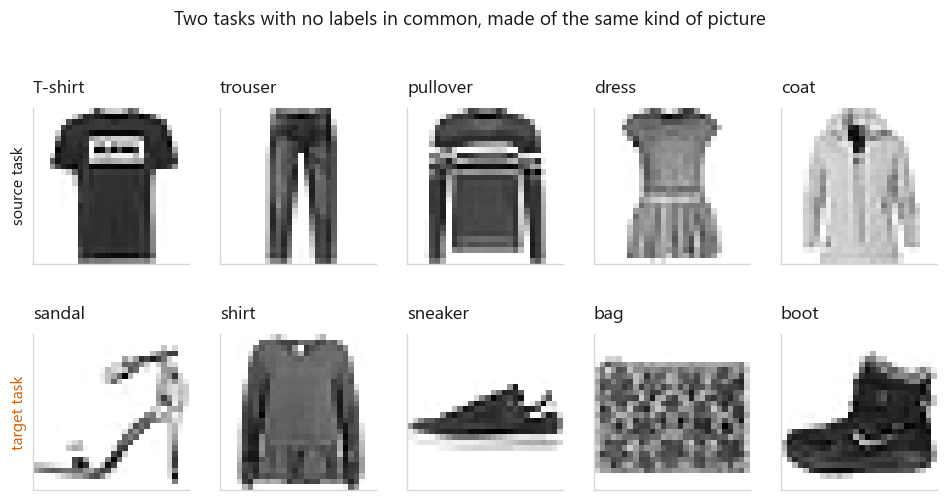

In [3]:
first_of = {c: int(np.flatnonzero(np.asarray(torch.as_tensor(train_set.targets)) == c)[0])
            for c in range(10)}

fig, axes = plt.subplots(2, 5, figsize=(10.6, 4.9))
for column, (source_class, target_class) in enumerate(zip(SOURCE_CLASSES, TARGET_CLASSES)):
    for row, class_index in enumerate([source_class, target_class]):
        ax = axes[row, column]
        ax.imshow(train_set[first_of[class_index]][0].squeeze(), cmap="gray_r")
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        style.title(ax, CLASSES[class_index])
        ax.title.set_fontsize(9.5)
        ax.title.set_color(style.MUTED)
axes[0, 0].set_ylabel("source task", fontsize=10.5, color=style.INK)
axes[1, 0].set_ylabel("target task", fontsize=10.5, color=style.HIGHLIGHT)
fig.suptitle("Two tasks with no labels in common, made of the same kind of picture",
             x=0.5, y=1.03, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-two-tasks.png")

print("No garment appears in both rows. Whatever transfers is not memorised labels.")

## 2. What transfers and what does not

A trained network is a stack of representations, and they are not equally
reusable. The first convolution sees raw pixels and can only learn things that
are visible in a 3x3 window: an edge, a corner, a spot of contrast. That layer
would look almost the same if I had trained it on faces, or on satellite tiles,
or on chest scans, because those are all pictures and pictures are made of
edges. The second layer combines edges into small shapes. By the time you reach
the layer feeding the classifier, every unit has been shaped by the pressure to
separate the source classes specifically, and its meaning is something like
"trouser-ness". That last part is what does not transfer.

So the practical question is where to cut. Everything below the cut is copied
from the source model and frozen; everything above is fresh and trained on the
target. I will train the source model first, then cut at each depth and measure.

In [4]:
class SmallCNN(nn.Module):
    """The network from 08-02, split into named stages so I can copy them one by one."""

    def __init__(self, n_classes=5):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.embed = nn.Sequential(
            nn.Flatten(), nn.Linear(32 * 7 * 7, 64), nn.ReLU())
        self.head = nn.Linear(64, n_classes)

    def forward(self, x):
        return self.head(self.embed(self.block2(self.block1(x))))


# Deliberately no batch norm. Frozen batch-norm layers keep updating their running
# statistics unless you also switch them to eval mode, and that gotcha would
# quietly muddy every measurement below.
STAGES = ["block1", "block2", "embed"]


def accuracy(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (model(xb).argmax(1) == yb).sum().item()
            total += len(yb)
    return correct / total


torch.manual_seed(SEED)
source_model = SmallCNN(len(SOURCE_CLASSES)).to(device)
optimiser = torch.optim.SGD(source_model.parameters(), lr=0.05, momentum=0.9)
loss_fn = nn.CrossEntropyLoss()

started = time.perf_counter()
for _ in range(6):
    source_model.train()
    for xb, yb in source_train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimiser.zero_grad()
        loss_fn(source_model(xb), yb).backward()
        optimiser.step()

SOURCE_ACCURACY = accuracy(source_model, source_test_loader)
print(f"source model: {SOURCE_ACCURACY:.4f} on its own five classes, "
      f"trained in {time.perf_counter() - started:.0f} seconds")
print("This is the model everything below inherits from.")

source model: 0.9206 on its own five classes, trained in 21 seconds
This is the model everything below inherits from.


In [5]:
# The only part of this notebook that wants the internet. It is decoration: if it
# fails, one panel of one figure disappears and nothing else changes.
imagenet_filters = None
try:
    from torchvision.models import resnet18, ResNet18_Weights

    pretrained = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    imagenet_filters = pretrained.conv1.weight.detach().cpu()[:16]
    print("ImageNet weights loaded, so I can show a real pretrained first layer too")
except Exception as error:
    print(f"no pretrained weights this run ({type(error).__name__}) - "
          "carrying on with the source model trained above")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\pilot/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  2%|▏         | 896k/44.7M [00:00<00:08, 5.21MB/s]

  4%|▎         | 1.62M/44.7M [00:00<00:07, 6.31MB/s]

  6%|▌         | 2.50M/44.7M [00:00<00:05, 7.40MB/s]

...

 94%|█████████▍| 42.0M/44.7M [00:04<00:00, 9.05MB/s]

 96%|█████████▋| 43.0M/44.7M [00:04<00:00, 9.24MB/s]

 99%|█████████▉| 44.1M/44.7M [00:04<00:00, 9.61MB/s]

100%|██████████| 44.7M/44.7M [00:05<00:00, 9.26MB/s]

ImageNet weights loaded, so I can show a real pretrained first layer too


In [6]:
def balanced_subset(pool, labels, n, seed=SEED):
    """`n` target examples, the same number per class, nested as `n` grows."""
    rng = np.random.default_rng(seed)
    per_class = n // len(np.unique(labels))
    chosen = np.concatenate([rng.permutation(np.flatnonzero(labels == c))[:per_class]
                             for c in np.unique(labels)])
    return Subset(pool, rng.permutation(chosen).tolist())


STEPS = 400   # every run gets the same number of gradient updates, so the only
BATCH = 64    # thing being compared is where the weights started


def target_run(n_train, *, copy_stages=0, freeze_copied=False, head_lr=0.05,
               backbone_scale=0.1, steps=STEPS, seed=SEED, check_every=None):
    """Train one model on the target task and return it with its test accuracy.

    `copy_stages` says how many stages are inherited from the source model,
    `freeze_copied` whether they are held fixed, and `backbone_scale` how much
    slower the inherited weights move when they are not frozen.
    """
    torch.manual_seed(seed)
    model = SmallCNN(len(TARGET_CLASSES)).to(device)
    for name in STAGES[:copy_stages]:
        getattr(model, name).load_state_dict(getattr(source_model, name).state_dict())
        if freeze_copied:
            for parameter in getattr(model, name).parameters():
                parameter.requires_grad = False

    copied = [p for name in STAGES[:copy_stages] for p in getattr(model, name).parameters()]
    fresh = [p for name in STAGES[copy_stages:] for p in getattr(model, name).parameters()]
    fresh += list(model.head.parameters())

    groups = [{"params": fresh, "lr": head_lr}]
    if copied and not freeze_copied:
        groups.append({"params": copied, "lr": head_lr * backbone_scale})
    optimiser = torch.optim.SGD(groups, momentum=0.9)
    schedule = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=steps)
    loss_fn = nn.CrossEntropyLoss()

    subset = balanced_subset(target_pool, target_pool_labels, n_train, seed=seed)
    loader = DataLoader(subset, batch_size=min(BATCH, len(subset)), shuffle=True,
                        generator=torch.Generator().manual_seed(seed))

    history = {"step": [], "acc": []}
    step = 0
    model.train()
    while step < steps:
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimiser.zero_grad()
            loss_fn(model(xb), yb).backward()
            optimiser.step()
            schedule.step()
            step += 1
            if check_every and step % check_every == 0:
                history["step"].append(step)
                history["acc"].append(accuracy(model, target_test_loader))
                model.train()
            if step >= steps:
                break
    return model, accuracy(model, target_test_loader), history


print(f"every target run: {STEPS} updates, batch {BATCH}, same seed")

every target run: 400 updates, batch 64, same seed


In [7]:
# Cut the source model at each depth, freeze everything below the cut, train
# everything above it on the same small target set.
DEPTH_N = 500
depth_names = ["nothing (from scratch)", "block1", "block1 + block2",
               "block1 + block2 + embed"]
depth_scores = []
for depth in range(len(STAGES) + 1):
    _, score, _ = target_run(DEPTH_N, copy_stages=depth, freeze_copied=True)
    depth_scores.append(score)
    print(f"copied and frozen: {depth_names[depth]:<24} accuracy {score:.4f}")

best = int(np.argmax(depth_scores))
print(f"\nbest cut: {depth_names[best]}")
print(f"deepest cut minus best cut: {depth_scores[-1] - depth_scores[best]:+.4f}")

copied and frozen: nothing (from scratch)   accuracy 0.9224


copied and frozen: block1                   accuracy 0.9336


copied and frozen: block1 + block2          accuracy 0.9356


copied and frozen: block1 + block2 + embed  accuracy 0.8660

best cut: block1 + block2
deepest cut minus best cut: -0.0696


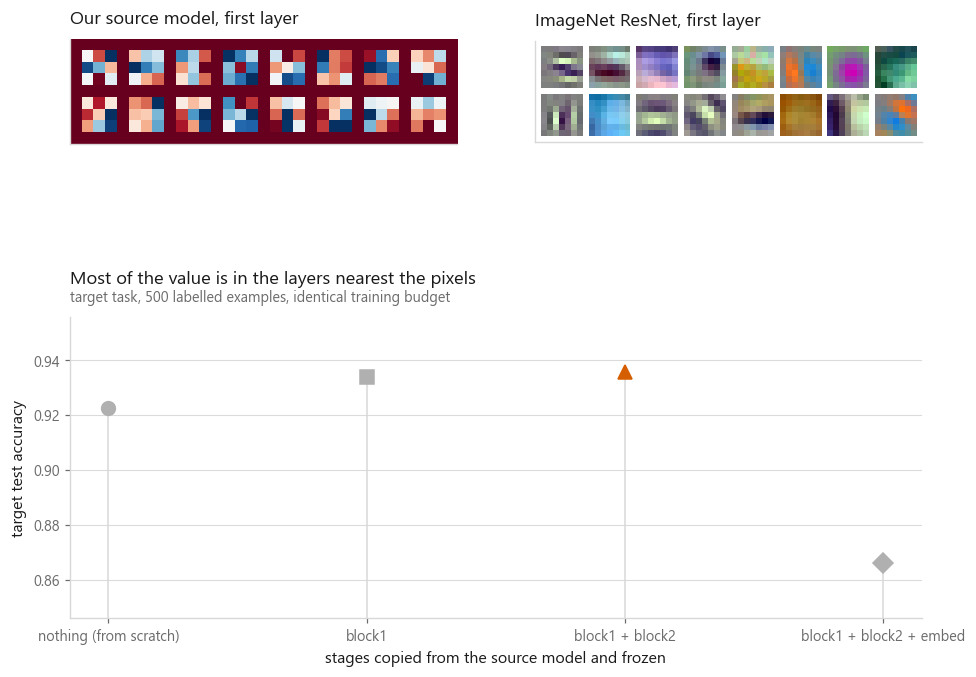

In [8]:
def montage(weights, cols=8, pad=1):
    """Tile a stack of filters into one image, each scaled symmetrically about zero."""
    array = weights.detach().cpu().numpy()
    n, channels, height, width = array.shape
    scale = np.abs(array).max(axis=(1, 2, 3), keepdims=True) + 1e-9
    array = array / scale * 0.5 + 0.5
    rows = int(np.ceil(n / cols))
    canvas = np.ones((rows * (height + pad) + pad, cols * (width + pad) + pad, channels))
    for i in range(n):
        row, column = divmod(i, cols)
        y, x = row * (height + pad) + pad, column * (width + pad) + pad
        canvas[y:y + height, x:x + width, :] = array[i].transpose(1, 2, 0)
    return canvas.squeeze(-1) if channels == 1 else canvas


fig = plt.figure(figsize=(10.0, 7.4))
grid = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.5], hspace=0.5)

if imagenet_filters is None:
    ax_ours = fig.add_subplot(grid[0, :])
else:
    ax_ours = fig.add_subplot(grid[0, 0])
    ax_them = fig.add_subplot(grid[0, 1])
    ax_them.imshow(montage(imagenet_filters))
    ax_them.set_xticks([]); ax_them.set_yticks([]); ax_them.grid(False)
    style.title(ax_them, "ImageNet ResNet, first layer")

ax_ours.imshow(montage(source_model.block1[0].weight), cmap="RdBu_r", vmin=0, vmax=1)
ax_ours.set_xticks([]); ax_ours.set_yticks([]); ax_ours.grid(False)
style.title(ax_ours, "Our source model, first layer")

ax_depth = fig.add_subplot(grid[1, :])
positions = np.arange(len(depth_scores))
depth_colours = style.spot(len(depth_scores), best)
ax_depth.vlines(positions, min(depth_scores) - 0.02, depth_scores,
                color=style.RULE, linewidth=1.0)
for position, score, colour, marker in zip(positions, depth_scores, depth_colours,
                                           style.MARKERS):
    ax_depth.plot(position, score, marker=marker, color=colour, markersize=9,
                  linestyle="none")
ax_depth.set_xticks(positions, depth_names, fontsize=9.5)
ax_depth.set_xlabel("stages copied from the source model and frozen")
ax_depth.set_ylabel("target test accuracy")
ax_depth.set_ylim(min(depth_scores) - 0.02, max(depth_scores) + 0.02)
style.title(ax_depth, "Most of the value is in the layers nearest the pixels",
            f"target task, {DEPTH_N} labelled examples, identical training budget")
style.save(fig, FIG / "fig-02-what-transfers.png")

The first-layer filters are the argument in one picture. Most of them are
oriented light and dark bands — edge detectors, at various angles — with a few
blob detectors. Nobody asked for them and nothing about sandals or trousers is
written into them. If the ImageNet panel rendered, compare the two. One network
was trained on a million colour photographs of a thousand categories and the
other on thirty thousand small greyscale clothes, and their first layers are
recognisably the same idea. That similarity is the whole basis of transfer.

The dot plot underneath measures the payoff per depth. Going from nothing to the
first block is a large jump, and the print above names which cut actually won.
Copying the deepest stage as well is where the returns flatten or turn negative,
because that stage has been shaped to answer the source question and my target
question is a different one.

## 3. Three strategies compared

There are three things you can do with the same target task, and they differ
only in what starts trained and what is allowed to move.

| | |
|---|---|
| **From scratch** | Random weights, everything trainable. The baseline that ignores the source model |
| **Feature extraction** | Copy the backbone, freeze it, train a new head. The backbone becomes a fixed function that turns images into vectors |
| **Fine-tuning** | Copy the backbone, train everything, but move the copied weights at a fraction of the head's learning rate |

Feature extraction has very few trainable parameters, which is exactly why it
survives tiny datasets: there is almost nothing to overfit. Its ceiling is lower,
because the features are stuck as the source task left them. Fine-tuning lets
those features adapt to the target, which is better if you have enough data to
steer them and worse if you do not.

In [9]:
strategies = {
    "from scratch": dict(copy_stages=0, freeze_copied=False),
    "feature extraction": dict(copy_stages=len(STAGES), freeze_copied=True),
    "fine-tuning": dict(copy_stages=len(STAGES), freeze_copied=False, backbone_scale=0.1),
}

FIXED_N = 500
curves = {}
for name, options in strategies.items():
    model, score, history = target_run(FIXED_N, check_every=40, **options)
    curves[name] = history
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"{name:<20} accuracy {score:.4f}   trainable {trainable:>7,} of {total:,}")

from scratch         accuracy 0.9210   trainable 105,541 of 105,541


feature extraction   accuracy 0.8660   trainable     325 of 105,541


fine-tuning          accuracy 0.9366   trainable 105,541 of 105,541


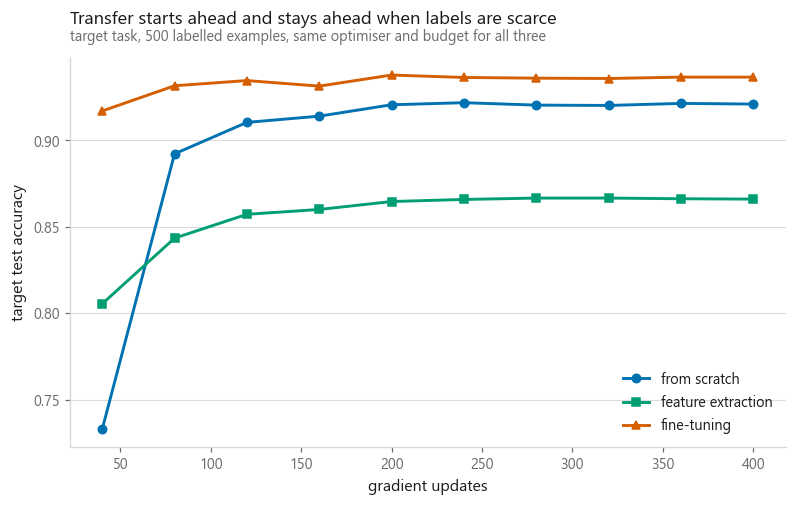

In [10]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
colours = [style.PALETTE[0], style.PALETTE[2], style.HIGHLIGHT]
for i, (name, history) in enumerate(curves.items()):
    ax.plot(history["step"], history["acc"], marker=style.MARKERS[i],
            color=colours[i], label=name)
ax.set_xlabel("gradient updates")
ax.set_ylabel("target test accuracy")
ax.legend(loc="lower right")
style.title(ax, "Transfer starts ahead and stays ahead when labels are scarce",
            f"target task, {FIXED_N} labelled examples, same optimiser and budget for all three")
style.save(fig, FIG / "fig-03-three-strategies.png")

Look at the left edge before you look at the right. The transferred models are
already useful after a handful of updates, because the only thing they have to
learn is a linear map from features that already separate garments. The
from-scratch model spends most of its budget rediscovering edge detectors that
were sitting in the source model the whole time.

## 4. How little data before it stops helping

This is the question that decides whether transfer learning is worth your
afternoon. Transfer cannot help forever: with enough target data, a model
trained from scratch will learn its own features, tuned to the target rather
than inherited from someone else's task, and catch up. The useful question is
therefore about the size of the dataset: at what point does transfer stop
mattering?

I sweep the size of the target training set and run all three strategies at each
size. That is eighteen training runs, which is why each one is deliberately
cheap: the same small network and the same fixed number of updates throughout.
Sizes are nested, so the smallest set is contained in every larger one and the
curves are not moving because the sample changed.

In [11]:
SIZES = [50, 100, 250, 500, 1000, 2500]

rows = []
started = time.perf_counter()
for n in SIZES:
    for name, options in strategies.items():
        _, score, _ = target_run(n, **options)
        rows.append({"target examples": n, "strategy": name, "accuracy": score})

sweep = (pd.DataFrame(rows)
         .pivot(index="target examples", columns="strategy", values="accuracy")
         .loc[:, list(strategies)])
print(sweep.round(4).to_string())
print(f"\n{len(rows)} runs in {time.perf_counter() - started:.0f} seconds")

gap = sweep["fine-tuning"] - sweep["from scratch"]
print("\nfine-tuning minus from scratch, by target-set size:")
print(gap.round(4).to_string())
print(f"\ngap at {SIZES[0]} examples: {gap.iloc[0]:+.4f}   "
      f"gap at {SIZES[-1]}: {gap.iloc[-1]:+.4f}   "
      f"shrinkage: {gap.iloc[0] - gap.iloc[-1]:+.4f}")

reference = sweep["fine-tuning"].iloc[0]
matched = sweep.index[sweep["from scratch"] >= reference]
if len(matched):
    print(f"from scratch needs {matched[0]} examples to match what fine-tuning "
          f"reached with {SIZES[0]}")
else:
    print(f"from scratch never matches fine-tuning's {SIZES[0]}-example score "
          f"within this sweep")

strategy         from scratch  feature extraction  fine-tuning
target examples                                               
50                     0.8022              0.7306       0.8136
100                    0.8634              0.8184       0.8860
250                    0.8914              0.8420       0.9116
500                    0.9216              0.8660       0.9366
1000                   0.9388              0.8708       0.9412
2500                   0.9496              0.8742       0.9514

18 runs in 112 seconds

fine-tuning minus from scratch, by target-set size:
target examples
50      0.0114
100     0.0226
250     0.0202
500     0.0150
1000    0.0024
2500    0.0018

gap at 50 examples: +0.0114   gap at 2500: +0.0018   shrinkage: +0.0096
from scratch needs 100 examples to match what fine-tuning reached with 50


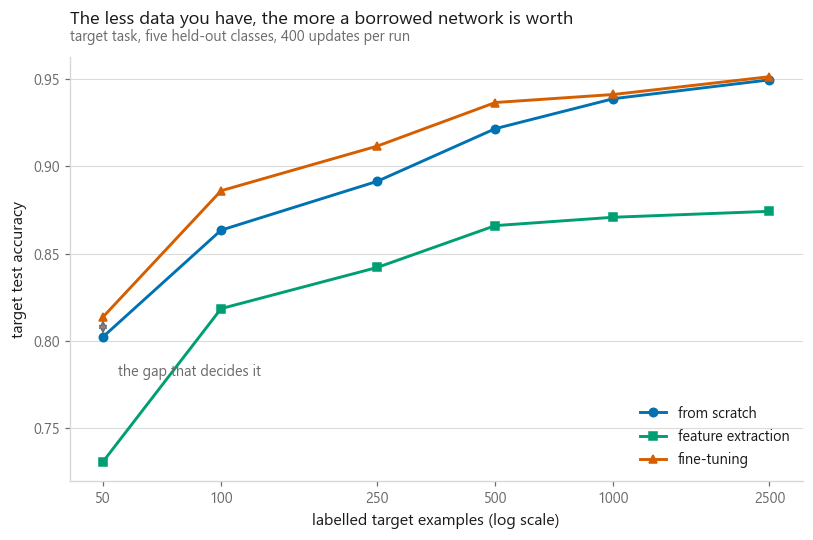

In [12]:
fig, ax = plt.subplots(figsize=(8.6, 5.0))
for i, name in enumerate(strategies):
    ax.plot(sweep.index, sweep[name], marker=style.MARKERS[i], color=colours[i],
            label=name)

ax.annotate("", xy=(SIZES[0], sweep["fine-tuning"].iloc[0]),
            xytext=(SIZES[0], sweep["from scratch"].iloc[0]),
            arrowprops=dict(arrowstyle="<->", color=style.MUTED, linewidth=1.1))
ax.annotate("the gap that decides it", xy=(SIZES[0], sweep.iloc[0].mean()),
            xytext=(10, 0), textcoords="offset points", va="center",
            fontsize=9.5, color=style.MUTED)

ax.set_xscale("log")
ax.set_xticks(SIZES, [str(s) for s in SIZES])
ax.minorticks_off()
ax.set_xlabel("labelled target examples (log scale)")
ax.set_ylabel("target test accuracy")
ax.legend(loc="lower right")
style.title(ax, "The less data you have, the more a borrowed network is worth",
            "target task, five held-out classes, 400 updates per run")
style.save(fig, FIG / "fig-04-how-little-data.png")

This is the figure to keep. Three things are in it.

At the left edge the gap is enormous. At the smallest size the from-scratch
model has nothing to work with, while the transferred models are only fitting a
small classifier on top of features that were paid for elsewhere. This is the
regime where transfer learning decides whether you have a working model at all.

The curves converge as the target set grows. Every extra label helps the
from-scratch model far more than it helps the others, because it is the only one
still learning its features from data. The printed gap says how much is left at
the largest size.

Then watch the two transfer curves against each other. Feature extraction has
the fewest trainable parameters, so it is the safer bet when data is scarcest,
and fine-tuning needs enough data to move the backbone without wrecking it. If
they cross in your run, the crossing point is the practical rule: freeze when
you have almost nothing, unfreeze as labels arrive.

## 5. Learning rates and forgetting

When you fine-tune, the copied weights are already close to something good. A
normal learning rate takes steps sized for a random initialisation, and those
steps are far too big here. Worse, the new head starts random, so its first
gradients are large and meaningless, and they flow straight back into the
backbone. A few hundred bad updates can undo everything the source training
bought before the target data has said anything useful.

So the backbone gets a smaller learning rate than the head, typically a tenth or
less. The standard recipe goes further: train the head alone for a short while,
then unfreeze, so that by the time gradients reach the backbone they mean
something.

The other cost of moving the backbone is **catastrophic forgetting**. The
features drift toward the target task, and the source task, which nobody is
measuring any more, quietly stops working. I can measure it directly: put the
original source head back on top of the fine-tuned backbone and score it on the
source test set. Nothing about the source head changed, so any loss is the
features having moved out from under it.

In [13]:
settings = [
    ("frozen backbone", dict(copy_stages=len(STAGES), freeze_copied=True)),
    ("backbone lr = head lr", dict(copy_stages=len(STAGES), backbone_scale=1.0)),
    ("backbone lr = head lr / 10", dict(copy_stages=len(STAGES), backbone_scale=0.1)),
    ("backbone lr = head lr / 100", dict(copy_stages=len(STAGES), backbone_scale=0.01)),
]

rows = []
for label, options in settings:
    tuned, score, _ = target_run(FIXED_N, **options)

    # The original source head, unchanged, on top of the moved backbone.
    probe = SmallCNN(len(SOURCE_CLASSES)).to(device)
    probe.load_state_dict(tuned.state_dict())
    probe.head.load_state_dict(source_model.head.state_dict())

    rows.append({"setting": label, "target accuracy": score,
                 "source accuracy after": accuracy(probe, source_test_loader)})

forgetting = pd.DataFrame(rows).set_index("setting")
print(f"source accuracy before any of this: {SOURCE_ACCURACY:.4f}\n")
print(forgetting.round(4).to_string())
print("\nthe last column is what the old task lost while the new one was learned")

source accuracy before any of this: 0.9206

                             target accuracy  source accuracy after
setting                                                            
frozen backbone                       0.8660                 0.9206
backbone lr = head lr                 0.9350                 0.6686
backbone lr = head lr / 10            0.9368                 0.8710
backbone lr = head lr / 100           0.9244                 0.9186

the last column is what the old task lost while the new one was learned


Two readings. Down the target column, look for the best value somewhere in the
middle of the range: too large a backbone rate destroys the features that were
handed over, too small and you may as well have frozen them. Across to the
source column, the faster the backbone was allowed to move, the less of the old
task survives. The frozen row is the sanity check — it has to come out exactly
at the source accuracy printed above, because those weights never moved.

For most work the forgetting does not matter, because you only care about the
new task. It matters when one model has to keep serving several tasks, or when
you fine-tune the same base model repeatedly and each round erases the last.
The cheap defences are to keep the source weights on disk, to freeze the lower
stages, and to mix a little source data back into training.

## Cheat sheet

| | |
|---|---|
| **Use it when** | You have a small labelled dataset and somebody has already trained a model on a similar kind of input |
| **Feature extraction** | Freeze the backbone, train a new head. Fewest trainable parameters, best when data is scarcest, lowest ceiling |
| **Fine-tuning** | Unfreeze the backbone at a fraction of the head's learning rate. Needs more data, higher ceiling |
| **From scratch** | Worth it when the target data is plentiful, or when the input is nothing like anything a public model has seen |
| **Learning rate** | Head at the normal rate, backbone at a tenth or less. Warm the head up first, then unfreeze |
| **Where to cut** | Freeze from the bottom. Early layers are generic, late layers belong to the source task |
| **Watch out** | Frozen batch-norm layers still update their running statistics unless you also put them in eval mode |
| **Watch out** | Match the source preprocessing exactly: same resize, same channel order, same normalisation |

## What to remember

1. Early layers learn edges and textures, which belong to images in general. Late
   layers learn the source task's categories. The deeper the layer, the less it
   transfers.
2. Feature extraction freezes the backbone and trains a head. Fine-tuning lets
   the backbone move slowly. From scratch throws the source model away.
3. The advantage of transfer is largest when labelled data is smallest, and it
   shrinks as the target set grows. The centrepiece figure is that statement.
4. Feature extraction is the safer choice at the smallest sizes, because it has
   almost nothing to overfit. Fine-tuning needs enough data to move the features
   without wrecking them, and repays it with a higher ceiling.
5. Fine-tune with a much smaller learning rate on the copied weights, because
   they start near a good solution and a random head sends noise into them.
6. Fine-tuning degrades the source task. Keep the original weights if you still
   need them.
7. Try feature extraction first. It is the cheapest experiment you can run, and
   it tells you whether the source features are any use before you spend anything.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [08-06 Image segmentation](../06-segmentation-intro/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#TransferLearning` `#FineTuning` `#ComputerVision` `#PyTorch`
`#FashionMNIST` `#MachineLearning` `#Python` `#MLTutorial` `#AI`